# Feature Engineering

En esta etapa se crean nuevas variables a partir de las características fisicoquímicas del agua. El objetivo es representar patrones que pueden no ser capturados directamente por las variables originales, como rangos de pH, niveles altos de turbidez, carga mineral y posibles riesgos asociados a desinfección.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("water_potability_clean.csv")
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.036752,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.073455,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.073455,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [ ]:
# Crear una copia del DataFrame para trabajar 
df_features = df.copy()

## Variable 1 - ph fuera de rango
- Esta variable identifica si el pH de una muestra está fuera del rango de referencia 6.5 a 8.5. 
- Se crea para resumir en una señal binaria los casos en los que el agua presenta un pH demasiado ácido o demasiado alcalino.

In [3]:
df_features['ph_fuera_rango'] = (
    (df_features['ph'] < 6.5) | 
    (df_features['ph'] > 8.5)
).astype(int)

df_features[['ph', 'ph_fuera_rango']].head()

,ph,ph_fuera_rango
0,7.036752,0
1,3.716080,1
2,8.099124,0
3,8.316766,0
4,9.092223,1


In [28]:
df_features['ph_fuera_rango'].value_counts()

ph_fuera_rango
0    1690
1    1455
Name: count, dtype: int64

In [30]:
df_features['ph_fuera_rango'].value_counts(normalize=True) * 100

ph_fuera_rango
0    53.736089
1    46.263911
Name: proportion, dtype: float64

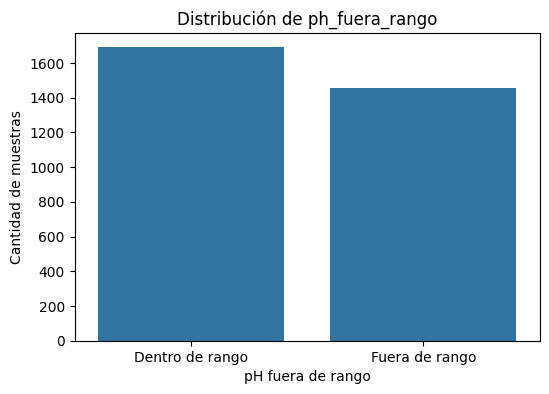

In [29]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df_features, x='ph_fuera_rango')

plt.title('Distribución de ph_fuera_rango')
plt.xlabel('pH fuera de rango')
plt.ylabel('Cantidad de muestras')
plt.xticks([0, 1], ['Dentro de rango', 'Fuera de rango'])

plt.show()

## Variable 2: ph categoria

La variable ph_categoria clasifica el pH del agua en tres grupos: ácida, aceptable o alcalina.  
Esta transformación permite interpretar mejor el comportamiento del pH, ya que tanto valores muy bajos como muy altos pueden representar condiciones no ideales para el agua.

In [4]:
def categorizar_ph(valor):
    if valor < 6.5:
        return 'Acida'
    elif valor <= 8.5:
        return 'Aceptable'
    else:
        return 'Alcalina'

df_features['ph_categoria'] = df_features['ph'].apply(categorizar_ph)

df_features[['ph', 'ph_categoria']].head()

,ph,ph_categoria
0,7.036752,Aceptable
1,3.716080,Acida
2,8.099124,Aceptable
3,8.316766,Aceptable
4,9.092223,Alcalina


In [5]:
df_features['ph_categoria'].value_counts()

ph_categoria
Aceptable    1690
Acida         967
Alcalina      488
Name: count, dtype: int64

In [6]:
df_features['ph_categoria'].value_counts(normalize=True) * 100

ph_categoria
Aceptable    53.736089
Acida        30.747218
Alcalina     15.516693
Name: proportion, dtype: float64

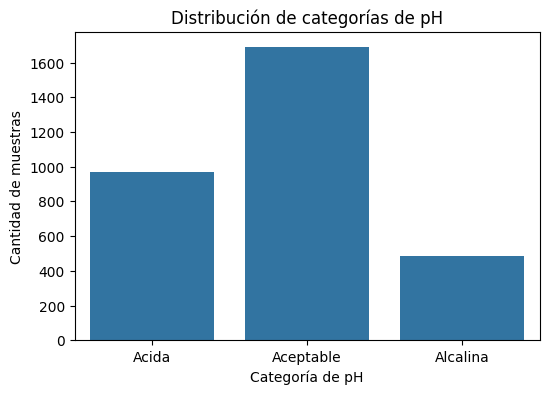

In [7]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_features,
    x='ph_categoria',
    order=['Acida', 'Aceptable', 'Alcalina']
)

plt.title('Distribución de categorías de pH')
plt.xlabel('Categoría de pH')
plt.ylabel('Cantidad de muestras')

plt.show()

La variable `ph_categoria` permite observar cuántas muestras se encuentran en rangos ácidos, aceptables o alcalinos. Esta categorización facilita la interpretación del pH y puede ser útil para el análisis posterior.

## Variable 3: turbidez alta

La turbidez indica qué tan clara o turbia está el agua. Una turbidez alta puede estar relacionada con partículas suspendidas, sedimentos o menor claridad del agua.

Para crear esta variable se utiliza el percentil 75 del dataset. Las muestras con turbidez por encima de ese valor se consideran de turbidez alta.

In [9]:
limite_turbidez = np.percentile(df_features['Turbidity'], 75)

limite_turbidez

np.float64(4.502138213738983)

In [10]:
df_features['turbidez_alta'] = (
    df_features['Turbidity'] > limite_turbidez
).astype(int)

df_features[['Turbidity', 'turbidez_alta']].head()

,Turbidity,turbidez_alta
0,2.963135,0
1,4.500656,0
2,3.055934,0
3,4.628771,1
4,4.075075,0


In [11]:
df_features['turbidez_alta'].value_counts()


turbidez_alta
0    2359
1     786
Name: count, dtype: int64

In [12]:
df_features['turbidez_alta'].value_counts(normalize=True) * 100

turbidez_alta
0    75.007949
1    24.992051
Name: proportion, dtype: float64

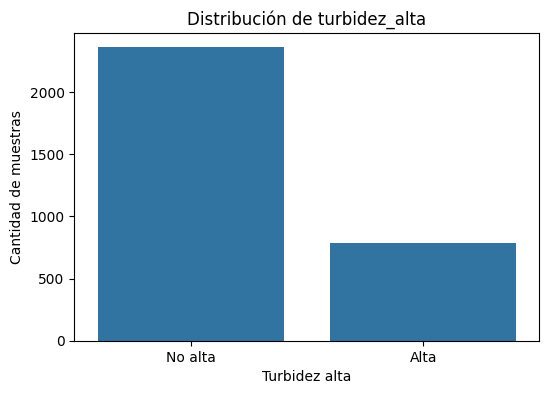

In [13]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df_features, x='turbidez_alta')

plt.title('Distribución de turbidez_alta')
plt.xlabel('Turbidez alta')
plt.ylabel('Cantidad de muestras')
plt.xticks([0, 1], ['No alta', 'Alta'])

plt.show()

## Variable 4: riesgo_desinfeccion

La variable riesgo_desinfeccion resume la presencia de valores altos en variables relacionadas con procesos de desinfección del agua.

Se consideran `Chloramines`, `Trihalomethanes` y `Organic_carbon`, ya que las cloraminas se asocian con desinfección, los trihalometanos pueden aparecer como subproductos de estos procesos y el carbono orgánico puede participar en reacciones que favorecen la formación de dichos subproductos.

Para evitar usar umbrales externos que podrían no coincidir con la escala del dataset, se considera como valor alto aquel que supera el percentil 75 de su propia variable.

In [14]:
limite_chloramines = np.percentile(df_features['Chloramines'], 75)
limite_trihalomethanes = np.percentile(df_features['Trihalomethanes'], 75)
limite_organic_carbon = np.percentile(df_features['Organic_carbon'], 75)

print("Límite Chloramines:", limite_chloramines)
print("Límite Trihalomethanes:", limite_trihalomethanes)
print("Límite Organic Carbon:", limite_organic_carbon)

Límite Chloramines: 8.108317979962136
Límite Trihalomethanes: 76.83122644607027
Límite Organic Carbon: 16.563116383698457


In [15]:
df_features['riesgo_desinfeccion'] = (
    (df_features['Chloramines'] > limite_chloramines).astype(int) +
    (df_features['Trihalomethanes'] > limite_trihalomethanes).astype(int) +
    (df_features['Organic_carbon'] > limite_organic_carbon).astype(int)
)

df_features[
    ['Chloramines', 'Trihalomethanes', 'Organic_carbon', 'riesgo_desinfeccion']
].head()

,Chloramines,Trihalomethanes,Organic_carbon,riesgo_desinfeccion
0,7.300212,86.990970,10.379783,1
1,6.635246,56.329076,15.180013,0
2,9.275884,66.420093,16.868637,2
3,8.059332,100.341674,18.436524,2
4,6.546600,31.997993,11.558279,0


0 = ninguna variable alta
1 = una variable alta
2 = dos variables altas
3 = tres variables altas

In [16]:
df_features['riesgo_desinfeccion'].value_counts().sort_index()

riesgo_desinfeccion
0    1315
1    1353
2     426
3      51
Name: count, dtype: int64

In [17]:
df_features['riesgo_desinfeccion'].value_counts(normalize=True).sort_index() * 100

riesgo_desinfeccion
0    41.812401
1    43.020668
2    13.545310
3     1.621622
Name: proportion, dtype: float64

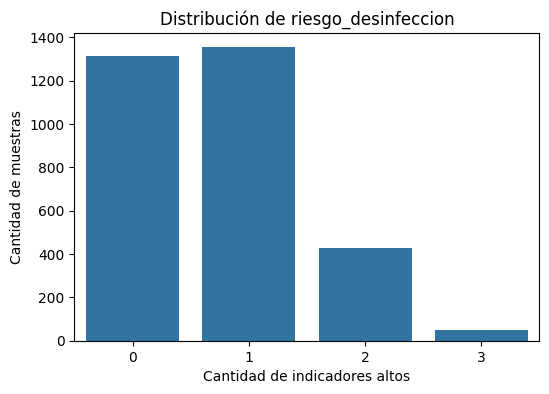

In [18]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df_features, x='riesgo_desinfeccion')

plt.title('Distribución de riesgo_desinfeccion')
plt.xlabel('Cantidad de indicadores altos')
plt.ylabel('Cantidad de muestras')

plt.show()

## Variable 5: carga_mineral_alta

La variable carga_mineral_alta resume la presencia de valores altos en características relacionadas con minerales, sales o iones disueltos en el agua.

Se consideran `Hardness`, `Solids`, `Sulfate` y `Conductivity`, ya que estas variables describen distintos aspectos de la carga mineral o iónica del agua.

Para definir valores altos se utiliza el percentil 75 de cada variable dentro del dataset, evitando aplicar umbrales externos que podrían no coincidir con la escala de los datos.

In [19]:
limite_hardness = np.percentile(df_features['Hardness'], 75)
limite_solids = np.percentile(df_features['Solids'], 75)
limite_sulfate = np.percentile(df_features['Sulfate'], 75)
limite_conductivity = np.percentile(df_features['Conductivity'], 75)

print("Límite Hardness:", limite_hardness)
print("Límite Solids:", limite_solids)
print("Límite Sulfate:", limite_sulfate)
print("Límite Conductivity:", limite_conductivity)

Límite Hardness: 216.67386912339217
Límite Solids: 27336.962623971183
Límite Sulfate: 351.21496237157373
Límite Conductivity: 482.3300548094984


In [20]:
df_features['carga_mineral_alta'] = (
    (df_features['Hardness'] > limite_hardness).astype(int) +
    (df_features['Solids'] > limite_solids).astype(int) +
    (df_features['Sulfate'] > limite_sulfate).astype(int) +
    (df_features['Conductivity'] > limite_conductivity).astype(int)
)

df_features[
    ['Hardness', 'Solids', 'Sulfate', 'Conductivity', 'carga_mineral_alta']
].head()

,Hardness,Solids,Sulfate,Conductivity,carga_mineral_alta
0,204.890455,20791.318981,368.516441,564.308654,2
1,129.422921,18630.057858,333.073455,592.885359,1
2,224.236259,19909.541732,333.073455,418.606213,1
3,214.373394,22018.417441,356.886136,363.266516,1
4,181.101509,17978.986339,310.135738,398.410813,0


0 = ningún indicador mineral alto
1 = un indicador alto
2 = dos indicadores altos
3 = tres indicadores altos
4 = cuatro indicadores altos

In [21]:
df_features['carga_mineral_alta'].value_counts().sort_index()

carga_mineral_alta
0     962
1    1389
2     634
3     153
4       7
Name: count, dtype: int64

In [22]:
df_features['carga_mineral_alta'].value_counts(normalize=True).sort_index() * 100

carga_mineral_alta
0    30.588235
1    44.165342
2    20.158983
3     4.864865
4     0.222576
Name: proportion, dtype: float64

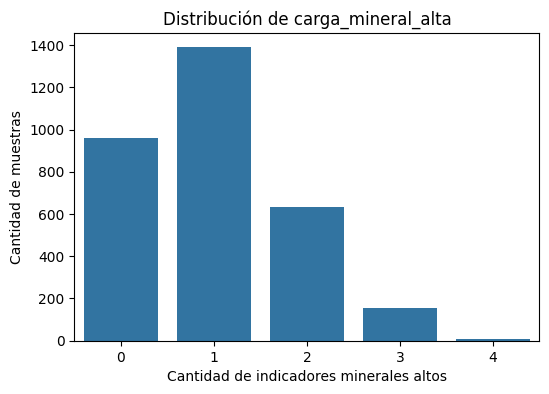

In [23]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df_features, x='carga_mineral_alta')

plt.title('Distribución de carga_mineral_alta')
plt.xlabel('Cantidad de indicadores minerales altos')
plt.ylabel('Cantidad de muestras')

plt.show()

Las variables creadas se basan en criterios físico-químicos relacionados con la calidad del agua. No se construyeron de forma arbitraria, sino agrupando variables que representan fenómenos similares: equilibrio ácido-base, turbidez, desinfección y carga mineral.

Además, se evitaron umbrales externos demasiado rígidos cuando no coincidían con la escala del dataset. Por eso, algunas variables utilizan el percentil 75 como referencia interna para identificar valores altos dentro de la propia base de datos.

Las nuevas características no reemplazan a las variables originales, sino que agregan representaciones adicionales que pueden ayudar al modelo a capturar patrones combinados.

In [24]:
df_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 3145 entries, 0 to 3144
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ph                   3145 non-null   float64
 1   Hardness             3145 non-null   float64
 2   Solids               3145 non-null   float64
 3   Chloramines          3145 non-null   float64
 4   Sulfate              3145 non-null   float64
 5   Conductivity         3145 non-null   float64
 6   Organic_carbon       3145 non-null   float64
 7   Trihalomethanes      3145 non-null   float64
 8   Turbidity            3145 non-null   float64
 9   Potability           3145 non-null   int64  
 10  ph_fuera_rango       3145 non-null   int64  
 11  ph_categoria         3145 non-null   str    
 12  turbidez_alta        3145 non-null   int64  
 13  riesgo_desinfeccion  3145 non-null   int64  
 14  carga_mineral_alta   3145 non-null   int64  
dtypes: float64(9), int64(5), str(1)
memory usage: 368

### Cambio de variable categorica a dummie

In [25]:
df_features = pd.get_dummies(
    df_features,
    columns=['ph_categoria'],
    drop_first=True
)

df_features.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,ph_fuera_rango,turbidez_alta,riesgo_desinfeccion,carga_mineral_alta,ph_categoria_Acida,ph_categoria_Alcalina
0,7.036752,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0,0,0,1,2,False,False
1,3.716080,129.422921,18630.057858,6.635246,333.073455,592.885359,15.180013,56.329076,4.500656,0,1,0,0,1,True,False
2,8.099124,224.236259,19909.541732,9.275884,333.073455,418.606213,16.868637,66.420093,3.055934,0,0,0,2,1,False,False
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0,0,1,2,1,False,False
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0,1,0,0,0,False,True


In [26]:
columnas_bool = df_features.select_dtypes(include='bool').columns

df_features[columnas_bool] = df_features[columnas_bool].astype(int)

df_features.dtypes

ph                       float64
Hardness                 float64
Solids                   float64
Chloramines              float64
Sulfate                  float64
Conductivity             float64
Organic_carbon           float64
Trihalomethanes          float64
Turbidity                float64
Potability                 int64
ph_fuera_rango             int64
turbidez_alta              int64
riesgo_desinfeccion        int64
carga_mineral_alta         int64
ph_categoria_Acida         int64
ph_categoria_Alcalina      int64
dtype: object

In [27]:
df_features.to_csv("water_potability_features.csv", index=False)

## Conclusión de Feature Engineering

- Se crearon nuevas variables a partir de criterios físico-químicos del agua.
- `ph_fuera_rango` identifica muestras con pH fuera del rango de referencia.
- `ph_categoria` clasifica el pH en ácido, aceptable o alcalino.
- `turbidez_alta` identifica muestras con turbidez alta respecto al dataset.
- `riesgo_desinfeccion` resume indicadores relacionados con desinfección y subproductos.
- `carga_mineral_alta` resume indicadores asociados a minerales, sales e iones disueltos.
- La variable categórica `ph_categoria` fue codificada para dejar el dataset listo para Machine Learning.
- El dataset final quedó preparado para la etapa de modelado.